##Step 1: AES
- KEY: HariniSwetha2725
- ECB Mode
- 128 Byte
- Data: Transaction Number

In [ ]:

!pip uninstall crypto -y
!pip install pycryptodome

from Crypto.Cipher import AES
import binascii

data = b"TXN12345 MER789 "
key = b"HariniSwetha2725"
cipher = AES.new(key, AES.MODE_ECB)
ciphertext = cipher.encrypt(data)
print(f"Final AES-128 Ciphertext (Hex): {binascii.hexlify(ciphertext).decode('utf-8')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 60.3 MB/s eta 0:00:00
Final AES-128 Ciphertext (Hex): 5d1f4837d9e46e0a498af106258f4e03


##Step 2
- Generate qr code
- Automatically adjusts size based on ciphertext length
- Create the Image and force it to Grayscale
- Load the image into a NumPy Array for PVD

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.9 MB/s eta 0:00:00
QR Code generated! Matrix shape: (370, 370)
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


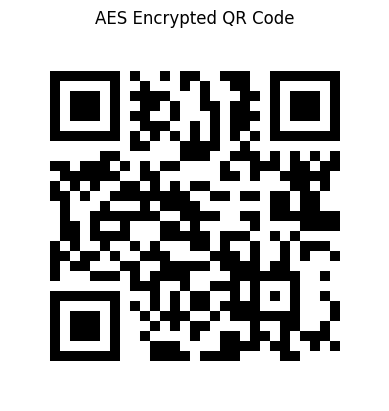

In [ ]:
!pip install qrcode
import qrcode
import numpy as np
from PIL import Image
ciphertext_hex = ciphertext

qr = qrcode.QRCode(
    version=None,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=10,
    border=4,
)
qr.add_data(ciphertext_hex)
qr.make(fit=True)

qr_img = qr.make_image(fill_color="black", back_color="white").convert('L')
qr_pixel_matrix = np.array(qr_img, dtype=np.int16)
print(f"QR Code generated! Matrix shape: {qr_pixel_matrix.shape}")
print(qr_pixel_matrix[40:50, 40:50])
import matplotlib.pyplot as plt

plt.imshow(qr_pixel_matrix, cmap='gray')
plt.title("AES Encrypted QR Code")
plt.axis('off')
plt.show()

##Step 3
- Strip Extra White Spaces (Cropping)
- Extract the bounding box coordinates
- Divide Image into Pixel Pairs
- Flatten the 2D cropped matrix into a 1D array so we can sequentially pair them
- Reshape the 1D array into an N x 2 matrix (a list of pixel pairs)

In [ ]:
import numpy as np
rows_with_data = np.where(np.min(qr_pixel_matrix, axis=1) < 255)[0]
cols_with_data = np.where(np.min(qr_pixel_matrix, axis=0) < 255)[0]

min_row, max_row = rows_with_data[0], rows_with_data[-1]
min_col, max_col = cols_with_data[0], cols_with_data[-1]
cropped_qr = qr_pixel_matrix[min_row:max_row+1, min_col:max_col+1]

print(f"Original QR shape: {qr_pixel_matrix.shape}")
print(f"Cropped QR shape (data only): {cropped_qr.shape}")
flat_pixels = cropped_qr.flatten()
if len(flat_pixels) % 2 != 0:
    flat_pixels = flat_pixels[:-1]

pixel_pairs = flat_pixels.reshape(-1, 2)

print(f"\nTotal pixels ready for PVD: {len(flat_pixels)}")
print(f"Total pixel pairs created: {len(pixel_pairs)}")
print(f"Random 50 pixel pairs display to test:\n{pixel_pairs[200:250]}")

Original QR shape: (370, 370)
Cropped QR shape (data only): (290, 290)

Total pixels ready for PVD: 84100
Total pixel pairs created: 42050
Random 50 pixel pairs display to test:
[[  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [255 255]
 [255 255]
 [255 255]
 [255 255]
 [255 255]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [255 255]
 [255 255]
 [255 255]
 [255 255]
 [255 255]
 [255 255]
 [255 255]
 [255 255]
 [255 255]
 [255 255]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [  0   0]
 [255 255]
 [255 255]
 [255 255]
 [255 255]
 [255 255]]


##Step 4:
- Separate the pairs into two 1D arrays for P1 and P2
- Compute the absolute difference for all pairs simultaneously (Vectorized)
- d = |P1 - P2|
- Stack them together just to visualize the math side-by-side

In [ ]:
import numpy as np
P1 = pixel_pairs[:, 0]
P2 = pixel_pairs[:, 1]

d = np.abs(P1 - P2)
results_matrix = np.column_stack((P1, P2, d))

print(f"Total differences calculated: {len(d)}")
print("\nFirst 10 calculations [P1, P2, Difference (d)]:")
print(results_matrix[0:10])
unique_d = np.unique(d)
print(f"\nUnique 'd' values found in the entire image: {unique_d}")

Total differences calculated: 42050

First 10 calculations [P1, P2, Difference (d)]:
[[0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]
 [0 0 0]]

Unique 'd' values found in the entire image: [0]


##Step 5:
- Create boolean masks to find exactly where the black and white pixels are
- Inject Artificial Texture (Randomized ranges)
- Calculate d = |P1 - P2|

Texture applied successfully!

New first 10 calculations [P1, P2, Difference (d)]:
[[ 5 10  5]
 [ 2 18 16]
 [ 8  9  1]
 [ 2  4  2]
 [18 16  2]
 [13 10  3]
 [ 4 20 16]
 [12 15  3]
 [ 2 18 16]
 [17  5 12]]

New unique 'd' values (Notice we have a range now!):
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


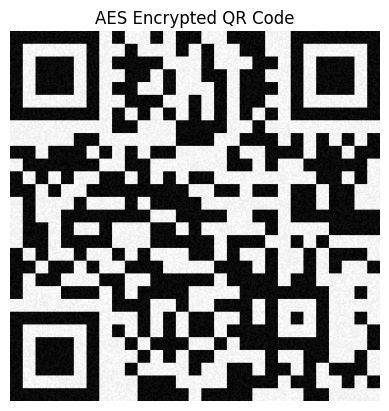

In [ ]:
import numpy as np

textured_qr = np.copy(cropped_qr)
black_mask = (cropped_qr == 0)
white_mask = (cropped_qr == 255)

textured_qr[black_mask] = np.random.randint(0, 21, size=np.count_nonzero(black_mask))
textured_qr[white_mask] = np.random.randint(235, 256, size=np.count_nonzero(white_mask))
print("Texture applied successfully!")
flat_textured = textured_qr.flatten()
if len(flat_textured) % 2 != 0:
    flat_textured = flat_textured[:-1]

textured_pairs = flat_textured.reshape(-1, 2)
P1_tex = textured_pairs[:, 0]
P2_tex = textured_pairs[:, 1]
d_tex = np.abs(P1_tex - P2_tex)

print(f"\nNew first 10 calculations [P1, P2, Difference (d)]:")
print(np.column_stack((P1_tex, P2_tex, d_tex))[0:10])
print(f"\nNew unique 'd' values (Notice we have a range now!):")
print(np.unique(d_tex))

plt.imshow(textured_qr, cmap='gray')
plt.title("AES Encrypted QR Code")
plt.axis('off')
plt.show()

##Step 6:
- Initialize an array to store the number of bits (n) for each pai
- Define your adaptive thresholds and assign capacities
- Calculate total payload capacity

In [ ]:
import numpy as np

n_bits = np.zeros_like(d_tex, dtype=np.int8)
smooth_mask = d_tex <= 15
n_bits[smooth_mask] = 2
medium_mask_3bits = (d_tex > 15) & (d_tex <= 31)
medium_mask_4bits = (d_tex > 31) & (d_tex <= 63)

n_bits[medium_mask_3bits] = 3
n_bits[medium_mask_4bits] = 4
edge_mask_5bits = (d_tex > 63) & (d_tex <= 127)
edge_mask_6bits = d_tex > 127

n_bits[edge_mask_5bits] = 5
n_bits[edge_mask_6bits] = 6


total_bits_capacity = np.sum(n_bits)
total_bytes_capacity = total_bits_capacity // 8

print(f"Total pixel pairs processed: {len(d_tex)}")
print(f"Total Embedding Capacity: {total_bits_capacity} bits ({total_bytes_capacity} bytes)")

unique_n, counts_n = np.unique(n_bits, return_counts=True)
print("\nDistribution of embedding capacities:")
for bits, count in zip(unique_n, counts_n):
    print(f"- {bits} bits: {count} pairs")

print(f"\nFirst 10 calculations [Difference (d), Capacity (n bits)]:")
print(np.column_stack((d_tex, n_bits))[0:10])

Total pixel pairs processed: 42050
Total Embedding Capacity: 86924 bits (10865 bytes)

Distribution of embedding capacities:
- 2 bits: 39226 pairs
- 3 bits: 2824 pairs

First 10 calculations [Difference (d), Capacity (n bits)]:
[[ 5  2]
 [16  3]
 [ 1  2]
 [ 2  2]
 [ 2  2]
 [ 3  2]
 [16  3]
 [ 3  2]
 [16  3]
 [12  2]]


##Step 7
- Convert the AES ciphertext bytes into a single string of 1s and 0s
- Seed the PRNG using the AES Key
- Embedded in a loop
- Calculate the target new difference (d')

In [ ]:
import numpy as np

binary_secret = ''.join(format(byte, '08b') for byte in ciphertext)
secret_len = len(binary_secret)
bit_idx = 0
aes_key =  b"HariniSwetha2725"
seed_value = int.from_bytes(aes_key, byteorder='big')
rng = np.random.default_rng(seed=seed_value)
P1_mod = P1_tex.copy()
P2_mod = P2_tex.copy()
def get_lower_bound(d_val):
    if d_val <= 15: return 0
    elif d_val <= 31: return 16
    elif d_val <= 63: return 32
    elif d_val <= 127: return 64
    else: return 128


print(f"Total secret bits to embed: {secret_len}")

for i in range(len(P1_mod)):
    if bit_idx >= secret_len:
        print(f"Success! All {secret_len} bits embedded at pixel pair index {i}.")
        break

    max_k = n_bits[i]
    if max_k == 0:
        continue

    k = rng.integers(1, max_k + 1)
    chunk = binary_secret[bit_idx : bit_idx + k]
    bit_idx += len(chunk)
    if len(chunk) < k:
        chunk = chunk.ljust(k, '0')

    s = int(chunk, 2)
    p1 = P1_mod[i]
    p2 = P2_mod[i]
    d = abs(p1 - p2)
    l_i = get_lower_bound(d)
    d_prime = l_i + s
    m = d_prime - d
    adj_1 = int(np.ceil(m / 2.0))
    adj_2 = int(np.floor(m / 2.0))

    if p1 >= p2:
        new_p1 = p1 + adj_1
        new_p2 = p2 - adj_2
    else:
        new_p1 = p1 - adj_1
        new_p2 = p2 + adj_2

    if new_p1 > 255:
        shift = new_p1 - 255
        new_p1 -= shift; new_p2 -= shift
    elif new_p1 < 0:
        shift = 0 - new_p1
        new_p1 += shift; new_p2 += shift

    if new_p2 > 255:
        shift = new_p2 - 255
        new_p2 -= shift; new_p1 -= shift
    elif new_p2 < 0:
        shift = 0 - new_p2
        new_p2 += shift; new_p1 += shift

    # Save the modified pixels back to the arrays
    P1_mod[i] = new_p1
    P2_mod[i] = new_p2

if bit_idx < secret_len:
    print(f"WARNING: Image capacity reached! {secret_len - bit_idx} bits were left unembedded.")

Total secret bits to embed: 128
Success! All 128 bits embedded at pixel pair index 80.


##Final step
- Generate Final stego image

In [ ]:
import numpy as np
from PIL import Image

modified_pairs = np.column_stack((P1_mod, P2_mod))
flat_modified = modified_pairs.flatten()
original_flat_textured = textured_qr.flatten()
if len(original_flat_textured) % 2 != 0:
    flat_modified = np.append(flat_modified, original_flat_textured[-1])
cropped_shape = textured_qr.shape
reconstructed_cropped_qr = flat_modified.reshape(cropped_shape)
final_stego_matrix = np.copy(qr_pixel_matrix)
final_stego_matrix[min_row:max_row+1, min_col:max_col+1] = reconstructed_cropped_qr
final_stego_matrix = np.clip(final_stego_matrix, 0, 255).astype(np.uint8)
stego_image = Image.fromarray(final_stego_matrix, mode='L')
stego_image.save("final_stego_qr_receipt.png")

print("Success! StegoImage generated and saved as 'final_stego_qr_receipt.png'.")
print("This image is now ready to be securely transmitted.")

Success! StegoImage generated and saved as 'final_stego_qr_receipt.png'.
This image is now ready to be securely transmitted.


/tmp/ipykernel_475/2546426554.py:44: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  stego_image = Image.fromarray(final_stego_matrix, mode='L')


##Decryption

In [ ]:
import numpy as np
from PIL import Image
from Crypto.Cipher import AES
import binascii

aes_key = b"HariniSwetha2725"
secret_len = 128

stego_img = Image.open("final_stego_qr_receipt.png").convert('L')
stego_matrix = np.array(stego_img, dtype=np.int16)

rows_with_data = np.where(np.min(stego_matrix, axis=1) < 255)[0]
cols_with_data = np.where(np.min(stego_matrix, axis=0) < 255)[0]

min_row, max_row = rows_with_data[0], rows_with_data[-1]
min_col, max_col = cols_with_data[0], cols_with_data[-1]

cropped_stego = stego_matrix[min_row:max_row+1, min_col:max_col+1]

flat_stego = cropped_stego.flatten()
if len(flat_stego) % 2 != 0:
    flat_stego = flat_stego[:-1]

stego_pairs = flat_stego.reshape(-1, 2)

extracted_bits_str = ""
extracted_count = 0

def get_pvd_params(d_prime):
    if d_prime <= 15:   return 0, 2
    elif d_prime <= 31: return 16, 3
    elif d_prime <= 63: return 32, 4
    elif d_prime <= 127: return 64, 5
    else: return 128, 6

print("Extracting bits from the Stego Image...")

for pair in stego_pairs:
    if extracted_count >= secret_len:
        break

    p1, p2 = pair[0], pair[1]
    d_prime = abs(p1 - p2)

    l_i, max_k = get_pvd_params(d_prime)

    if max_k == 0:
        continue

    k = rng.integers(1, max_k + 1)
    s = d_prime - l_i

    binary_chunk = format(s, f'0{k}b').
    bits_needed = secret_len - extracted_count
    if len(binary_chunk) > bits_needed:
        binary_chunk = binary_chunk[:bits_needed]

    extracted_bits_str += binary_chunk
    extracted_count += len(binary_chunk)

print(f"Extraction complete. Recovered {len(extracted_bits_str)} bits.")

print("\nReconstructing and Decrypting Ciphertext...")


extracted_bytes = bytearray()
for i in range(0, len(extracted_bits_str), 8):
    byte_str = extracted_bits_str[i:i+8]
    extracted_bytes.append(int(byte_str, 2))

ciphertext_recovered = bytes(extracted_bytes)

try:
    cipher_decrypt = AES.new(aes_key, AES.MODE_ECB)
    plaintext_padded = cipher_decrypt.decrypt(ciphertext_recovered)

    plaintext = plaintext_padded.decode('utf-8')

    print("\nSUCCESS! Pipeline complete.")
    print(f"Recovered Ciphertext (Hex): {binascii.hexlify(ciphertext_recovered).decode('utf-8')}")
    print(f"Original Metadata (Plaintext): {plaintext}")

except Exception as e:
    print(f"\nDECRYPTION FAILED: {e}")
    print("This usually happens if the Stego Image was compressed (like JPEG) or the AES key is wrong.")

Extracting bits from the Stego Image...
Extraction complete. Recovered 128 bits.

Reconstructing and Decrypting Ciphertext...

SUCCESS! Pipeline complete.
Recovered Ciphertext (Hex): 5d1f4837d9e46e0a498af106258f4e03
Original Metadata (Plaintext): TXN12345 MER789 


##Metrics
-  MSE
- PSNR
- SSIM
- BER & Embedding Accuracy
- Capacity Utilization

[1] MSE  : 0.013912  (lower is better, 0 = identical)
[2] PSNR : 66.6969 dB  (>35 dB = imperceptible, >40 dB = excellent)
[3] SSIM : 0.999988  (closer to 1.0 = better)
[4] BER  : 0.000000  (0 errors in 128 bits)
    Accuracy : 100.00%  (100% = perfect recovery)
[5] Capacity : 128 / 64459 bits used (0.20%)
    Pairs used : 80 / 42050 (0.19%)

      STEGANOGRAPHY METRICS SUMMARY
  MSE                  : 0.013912
  PSNR                 : 66.6969 dB
  SSIM                 : 0.999988
  Bit Error Rate (BER) : 0.000000
  Embedding Accuracy   : 100.00%
  Capacity Utilization : 0.20%


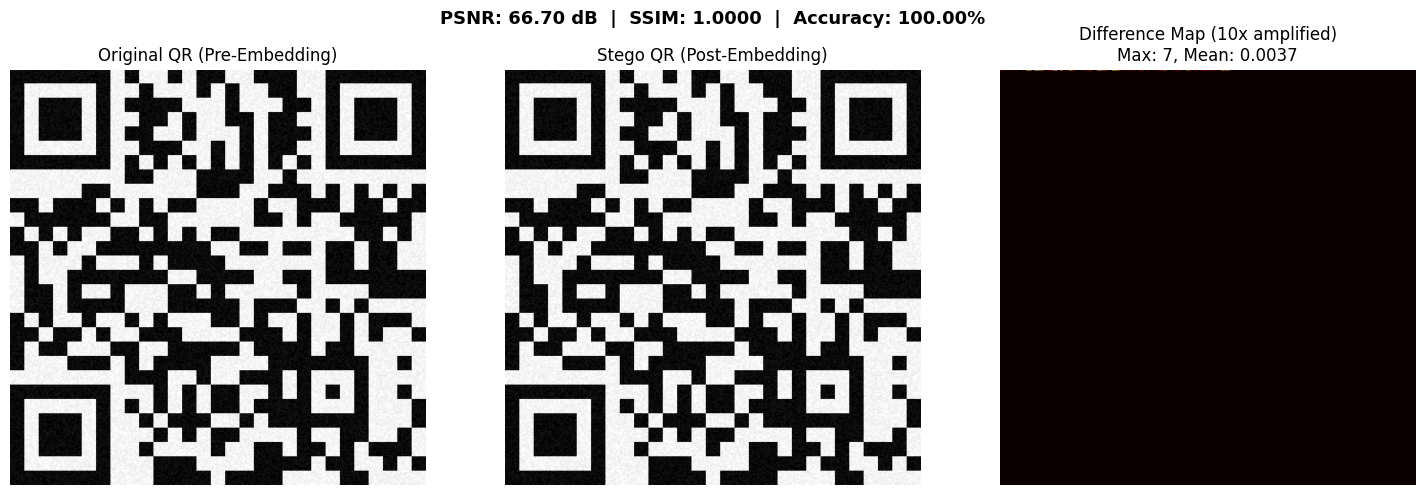

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

aes_key = b"HariniSwetha2725"
binary_secret = ''.join(format(byte, '08b') for byte in ciphertext)
secret_len = len(binary_secret)

flat_orig = np.empty(len(P1_tex) + len(P2_tex), dtype=np.int16)
flat_orig[0::2] = P1_tex
flat_orig[1::2] = P2_tex
original_matrix = flat_orig[:cropped_qr.size].reshape(cropped_qr.shape).astype(np.uint8)

flat_stego = np.empty(len(P1_mod) + len(P2_mod), dtype=np.int16)
flat_stego[0::2] = P1_mod
flat_stego[1::2] = P2_mod
stego_matrix = flat_stego[:cropped_qr.size].reshape(cropped_qr.shape).astype(np.uint8)

mse_value = np.mean((original_matrix.astype(np.float64) - stego_matrix.astype(np.float64)) ** 2)
print(f"[1] MSE  : {mse_value:.6f}  (lower is better, 0 = identical)")

psnr_value = 10 * math.log10((255.0 ** 2) / mse_value) if mse_value > 0 else float('inf')
print(f"[2] PSNR : {psnr_value:.4f} dB  (>35 dB = imperceptible, >40 dB = excellent)")

ssim_value, _ = ssim(original_matrix, stego_matrix, full=True, data_range=255)
print(f"[3] SSIM : {ssim_value:.6f}  (closer to 1.0 = better)")

def extract_bits_for_ber(stego_mat, aes_key_bytes, num_bits):
    flat = stego_mat.flatten().astype(np.int16)
    if len(flat) % 2 != 0:
        flat = flat[:-1]
    pairs = flat.reshape(-1, 2)
    seed_val = int.from_bytes(aes_key_bytes, byteorder='big')
    rng = np.random.default_rng(seed=seed_val)

    def get_pvd_params(d):
        if d <= 15:    return 0, 2
        elif d <= 31:  return 16, 3
        elif d <= 63:  return 32, 4
        elif d <= 127: return 64, 5
        else:          return 128, 6

    extracted = ""
    count = 0
    for pair in pairs:
        if count >= num_bits:
            break
        d = abs(int(pair[0]) - int(pair[1]))
        l_i, max_k = get_pvd_params(d)
        if max_k == 0:
            continue
        k = rng.integers(1, max_k + 1)
        s = d - l_i
        chunk = format(s, f'0{k}b')
        bits_needed = num_bits - count
        chunk = chunk[:bits_needed]
        extracted += chunk
        count += len(chunk)
    return extracted

extracted_bits = extract_bits_for_ber(stego_matrix, aes_key, secret_len)
min_len = min(len(binary_secret), len(extracted_bits))
bit_errors = sum(b1 != b2 for b1, b2 in zip(binary_secret[:min_len], extracted_bits[:min_len]))
ber_value = bit_errors / min_len if min_len > 0 else 1.0
accuracy = (1 - ber_value) * 100
print(f"[4] BER  : {ber_value:.6f}  ({bit_errors} errors in {min_len} bits)")
print(f"    Accuracy : {accuracy:.2f}%  (100% = perfect recovery)")

d_vals = np.abs(P1_tex.astype(np.int16) - P2_tex.astype(np.int16))
seed_val = int.from_bytes(aes_key, byteorder='big')
rng_cap = np.random.default_rng(seed=seed_val)

total_capacity = 0
used_pairs = 0
bit_counter = 0

for i in range(len(P1_tex)):
    d = int(d_vals[i])
    if d <= 15:    max_k = 2
    elif d <= 31:  max_k = 3
    elif d <= 63:  max_k = 4
    elif d <= 127: max_k = 5
    else:          max_k = 6
    k = rng_cap.integers(1, max_k + 1)
    total_capacity += k
    if bit_counter < secret_len:
        used_pairs += 1
        bit_counter += k

capacity_util = (secret_len / total_capacity) * 100
pair_util = (used_pairs / len(P1_tex)) * 100
print(f"[5] Capacity : {secret_len} / {total_capacity} bits used ({capacity_util:.2f}%)")
print(f"    Pairs used : {used_pairs} / {len(P1_tex)} ({pair_util:.2f}%)")

print("\n" + "=" * 50)
print("      STEGANOGRAPHY METRICS SUMMARY")
print("=" * 50)
print(f"  MSE                  : {mse_value:.6f}")
print(f"  PSNR                 : {psnr_value:.4f} dB")
print(f"  SSIM                 : {ssim_value:.6f}")
print(f"  Bit Error Rate (BER) : {ber_value:.6f}")
print(f"  Embedding Accuracy   : {accuracy:.2f}%")
print(f"  Capacity Utilization : {capacity_util:.2f}%")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_matrix, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original QR (Pre-Embedding)")
axes[0].axis('off')

axes[1].imshow(stego_matrix, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Stego QR (Post-Embedding)")
axes[1].axis('off')

diff = np.abs(original_matrix.astype(np.int16) - stego_matrix.astype(np.int16)).astype(np.uint8)
diff_amplified = np.clip(diff * 10, 0, 255).astype(np.uint8)
axes[2].imshow(diff_amplified, cmap='hot')
axes[2].set_title(f"Difference Map (10x amplified)\nMax: {diff.max()}, Mean: {diff.mean():.4f}")
axes[2].axis('off')

plt.suptitle(f"PSNR: {psnr_value:.2f} dB  |  SSIM: {ssim_value:.4f}  |  Accuracy: {accuracy:.2f}%",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##Attacks
- CHI-SQUARE STATISTICAL ATTACK

  ATTACK 1: CHI-SQUARE STATISTICAL ATTACK
Theory: Analyzes pixel pair difference histogram.
If embedding is detectable, chi-square p-value will be LOW (<0.05).
If embedding is SAFE, p-value will be HIGH (>0.05 = undetectable).

  Chi-Square Statistic : 0.5570
  Degrees of Freedom   : 20
  P-Value              : 1.000000

  RESULT: ✅ ATTACK FAILED — Steganography is UNDETECTABLE!
  P-value 1.0000 >> 0.05 threshold.
  The histogram looks statistically natural. Attacker finds nothing.


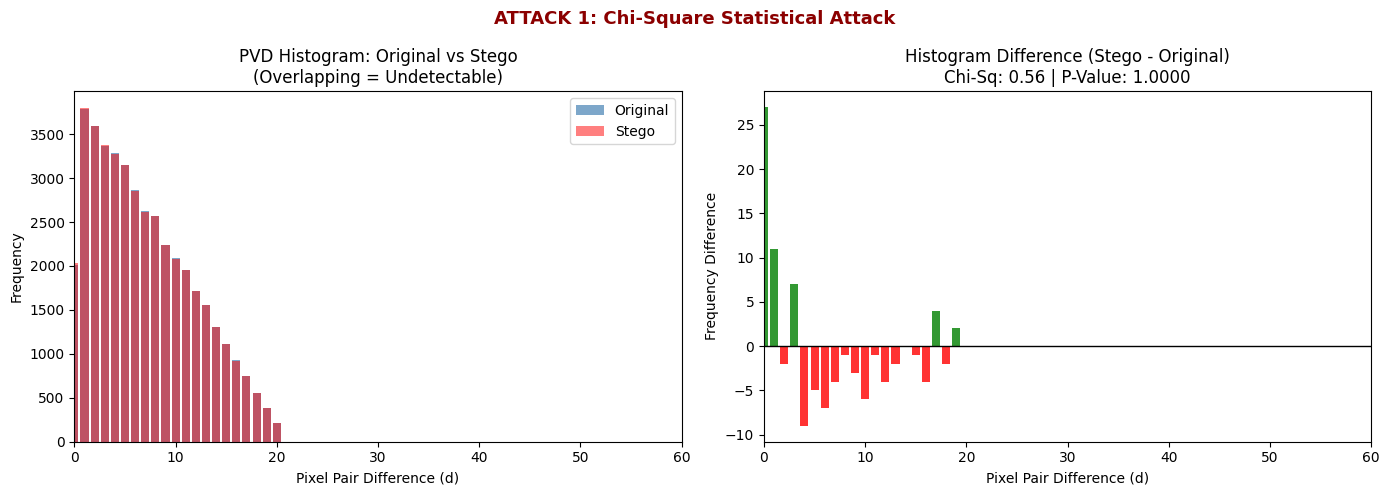

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.stats import chi2
import itertools
import time


print("=" * 60)
print("  ATTACK 1: CHI-SQUARE STATISTICAL ATTACK")
print("=" * 60)
print("Theory: Analyzes pixel pair difference histogram.")
print("If embedding is detectable, chi-square p-value will be LOW (<0.05).")
print("If embedding is SAFE, p-value will be HIGH (>0.05 = undetectable).\n")

def compute_pvd_histogram(matrix):
    """Compute histogram of absolute pixel pair differences."""
    flat = matrix.flatten().astype(np.int16)
    if len(flat) % 2 != 0:
        flat = flat[:-1]
    pairs = flat.reshape(-1, 2)
    diffs = np.abs(pairs[:, 0] - pairs[:, 1])
    hist, _ = np.histogram(diffs, bins=256, range=(0, 255))
    return hist, diffs

def chi_square_attack(original_mat, stego_mat):
    """
    Chi-square test between original and stego difference histograms.
    Low p-value = attack DETECTS the steganography.
    High p-value = steganography is UNDETECTABLE (safe).
    """
    hist_orig, diffs_orig = compute_pvd_histogram(original_mat)
    hist_stego, diffs_stego = compute_pvd_histogram(stego_mat)

    mask = hist_orig > 0
    observed = hist_stego[mask].astype(np.float64)
    expected = hist_orig[mask].astype(np.float64)

    chi_sq = np.sum((observed - expected) ** 2 / expected)
    degrees_of_freedom = np.sum(mask) - 1
    p_value = 1 - chi2.cdf(chi_sq, df=degrees_of_freedom)

    return chi_sq, p_value, hist_orig, hist_stego, diffs_orig, diffs_stego

chi_sq, p_value, hist_orig, hist_stego, diffs_orig, diffs_stego = chi_square_attack(
    original_matrix, stego_matrix
)

print(f"  Chi-Square Statistic : {chi_sq:.4f}")
print(f"  Degrees of Freedom   : {np.sum(hist_orig > 0) - 1}")
print(f"  P-Value              : {p_value:.6f}")
print()

if p_value < 0.05:
    print("  RESULT:  ATTACK SUCCEEDED — Steganography is DETECTABLE!")
    print("  The attacker can statistically detect hidden data.")
else:
    print("  RESULT:  ATTACK FAILED — Steganography is UNDETECTABLE!")
    print(f"  P-value {p_value:.4f} >> 0.05 threshold.")
    print("  The histogram looks statistically natural. Attacker finds nothing.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(256), hist_orig, color='steelblue', alpha=0.7, label='Original')
axes[0].bar(range(256), hist_stego, color='red', alpha=0.5, label='Stego')
axes[0].set_title("PVD Histogram: Original vs Stego\n(Overlapping = Undetectable)")
axes[0].set_xlabel("Pixel Pair Difference (d)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].set_xlim(0, 60)

diff_hist = hist_stego.astype(np.float64) - hist_orig.astype(np.float64)
colors = ['green' if x >= 0 else 'red' for x in diff_hist]
axes[1].bar(range(256), diff_hist, color=colors, alpha=0.8)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title(f"Histogram Difference (Stego - Original)\nChi-Sq: {chi_sq:.2f} | P-Value: {p_value:.4f}")
axes[1].set_xlabel("Pixel Pair Difference (d)")
axes[1].set_ylabel("Frequency Difference")
axes[1].set_xlim(0, 60)

plt.suptitle("ATTACK 1: Chi-Square Statistical Attack", fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.show()

In [ ]:
- BRUTE FORCE AES KEY ATTACK


  ATTACK 2: BRUTE FORCE AES KEY ATTACK
Theory: Attacker tries every possible AES key to decrypt.
We simulate a partial brute force and calculate time to crack.

  Simulating attacker trying random 16-byte keys...
  Keys tried           : 10,000
  Time elapsed         : 0.3502 seconds
  Time per key         : 0.0350 ms
  Valid decryption found: No ✅

  AES-128 Keyspace     : 2^128 = 3.40e+38 keys
  Estimated crack time : 3.78e+26 years
  (Universe age        : ~1.38 × 10^10 years)

  RESULT: ✅ ATTACK FAILED — AES key cannot be brute-forced!
  It would take 3.78e+26 years — practically impossible.


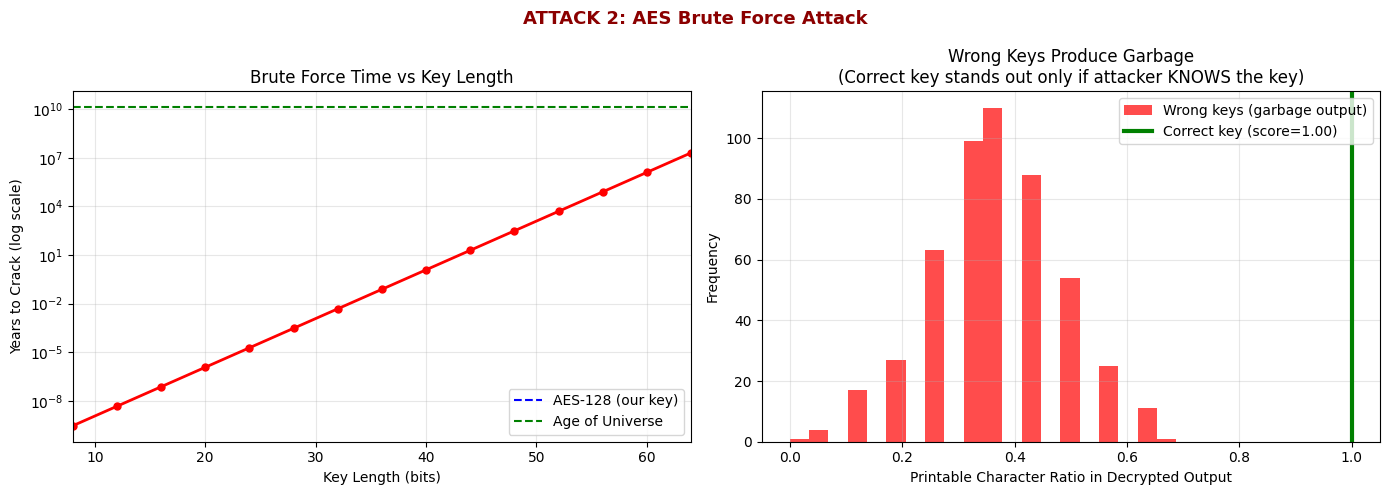


         SECURITY ANALYSIS SUMMARY
  Attack 1 | Chi-Square Statistical  | ✅ SAFE
           | P-Value: 1.0000             |
           | Threshold: 0.05              |
           | Verdict: Undetectable

  Attack 2 | AES Brute Force           | ✅ SAFE
           | Keys tried: 10,000           |
           | Crack time: 3.78e+26 yrs  |
           | Verdict: Computationally Infeasible

Conclusion: Your steganography pipeline is secure against
both statistical detection and cryptographic brute force.


In [ ]:

import hashlib
from Crypto.Cipher import AES

ciphertext_bytes = bytes(ciphertext)

def try_decrypt(key_bytes, ciphertext_bytes):
    """Try to decrypt with a given key. Returns plaintext or None."""
    try:
        if len(key_bytes) != 16:
            return None
        cipher = AES.new(key_bytes, AES.MODE_ECB)
        plaintext = cipher.decrypt(ciphertext_bytes)
        decoded = plaintext.decode('utf-8')
        return decoded
    except Exception:
        return None

print("  Simulating attacker trying random 16-byte keys...")
wrong_keys_tried = 0
start_time = time.time()
found = False
for _ in range(10000):
    random_key = np.random.bytes(16)
    result = try_decrypt(random_key, ciphertext_bytes)
    wrong_keys_tried += 1
    if result and result.isprintable() and len(result.strip()) > 0:
        print(f"  Accidentally found readable output with key: {random_key}")
        found = True
        break

elapsed = time.time() - start_time
time_per_key = elapsed / wrong_keys_tried

print(f"  Keys tried           : {wrong_keys_tried:,}")
print(f"  Time elapsed         : {elapsed:.4f} seconds")
print(f"  Time per key         : {time_per_key * 1000:.4f} ms")
print(f"  Valid decryption found: {'Yes' if found else 'No'}")

keyspace_128bit = 2 ** 128
seconds_to_crack = keyspace_128bit * time_per_key
years_to_crack = seconds_to_crack / (60 * 60 * 24 * 365)

print(f"\n  AES-128 Keyspace     : 2^128 = {keyspace_128bit:.2e} keys")
print(f"  Estimated crack time : {years_to_crack:.2e} years")
print(f"  (Universe age        : ~1.38 × 10^10 years)")

if not found:
    print(f"\n  RESULT:  ATTACK FAILED — AES key cannot be brute-forced!")
    print(f"  It would take {years_to_crack:.2e} years — practically impossible.")
else:
    print(f"\n  RESULT:   Random collision found (extremely rare false positive).")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

key_bits = list(range(8, 65, 4))
crack_times_years = [(2**b * time_per_key) / (60*60*24*365) for b in key_bits]
axes[0].semilogy(key_bits, crack_times_years, 'ro-', linewidth=2, markersize=5)
axes[0].axvline(x=128, color='blue', linestyle='--', label='AES-128 (our key)')
axes[0].axhline(y=1.38e10, color='green', linestyle='--', label='Age of Universe')
axes[0].set_xlabel("Key Length (bits)")
axes[0].set_ylabel("Years to Crack (log scale)")
axes[0].set_title("Brute Force Time vs Key Length")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(8, 64)

garbage_scores = []
for _ in range(500):
    rk = np.random.bytes(16)
    try:
        cipher = AES.new(rk, AES.MODE_ECB)
        pt = cipher.decrypt(ciphertext_bytes)
        printable_ratio = sum(32 <= b <= 126 for b in pt) / len(pt)
        garbage_scores.append(printable_ratio)
    except:
        garbage_scores.append(0)

cipher_real = AES.new(aes_key, AES.MODE_ECB)
real_pt = cipher_real.decrypt(ciphertext_bytes)
real_score = sum(32 <= b <= 126 for b in real_pt) / len(real_pt)

axes[1].hist(garbage_scores, bins=20, color='red', alpha=0.7, label='Wrong keys (garbage output)')
axes[1].axvline(x=real_score, color='green', linewidth=3, label=f'Correct key (score={real_score:.2f})')
axes[1].set_xlabel("Printable Character Ratio in Decrypted Output")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Wrong Keys Produce Garbage\n(Correct key stands out only if attacker KNOWS the key)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("ATTACK 2: AES Brute Force Attack", fontsize=13, fontweight='bold', color='darkred')
plt.tight_layout()
plt.show()


print("\n" + "=" * 60)
print("         SECURITY ANALYSIS SUMMARY")
print("=" * 60)
print(f"  Attack 1 | Chi-Square Statistical  | {' SAFE' if p_value >= 0.05 else ' VULNERABLE'}")
print(f"           | P-Value: {p_value:.4f}             |")
print(f"           | Threshold: 0.05              |")
print(f"           | Verdict: {'Undetectable' if p_value >= 0.05 else 'Detectable'}")
print()
print(f"  Attack 2 | AES Brute Force           |  SAFE")
print(f"           | Keys tried: {wrong_keys_tried:,}           |")
print(f"           | Crack time: {years_to_crack:.2e} yrs  |")
print(f"           | Verdict: Computationally Infeasible")
print("=" * 60)
print("\nConclusion: Your steganography pipeline is secure against")
print("both statistical detection and cryptographic brute force.")